In [ ]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [ ]:
# Paths

DATA_DIR = Path("../outputs/candidate_features")
OUTPUT_DIR = Path("../outputs/lasso/lasso_candidate_features")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEEPSEEK_FILE = DATA_DIR / "candidate_features_deepseek.csv"
GEMMA_FILE = DATA_DIR / "candidate_features_gemma.csv"

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Data directory: C:\Users\franc\OneDrive\Geop-Model\outputs\candidate_features
Output directory: C:\Users\franc\OneDrive\Geop-Model\outputs\lasso\lasso_candidate_features


In [4]:
# Load candidate feature datasets

deepseek = pd.read_csv(
    DEEPSEEK_FILE,
    parse_dates=["observation_date"]
)

gemma = pd.read_csv(
    GEMMA_FILE,
    parse_dates=["observation_date"]
)

print("DeepSeek:", deepseek.shape)
print("Gemma:", gemma.shape)

DeepSeek: (982, 126)
Gemma: (982, 126)


In [5]:
# Dataset sanity checks

TARGET = "DEXUSEU_logreturn"

print("DeepSeek shape:", deepseek.shape)
print("Gemma shape:", gemma.shape)

print(
    "\nIdentical dates:",
    deepseek["observation_date"].equals(
        gemma["observation_date"]
    )
)

print(
    "Identical targets:",
    np.allclose(
        deepseek[TARGET],
        gemma[TARGET]
    )
)

print(
    "\nDeepSeek missing values:",
    deepseek.isna().sum().sum()
)

print(
    "Gemma missing values:",
    gemma.isna().sum().sum()
)

print(
    "\nDate range:",
    deepseek["observation_date"].min(),
    "to",
    deepseek["observation_date"].max()
)

DeepSeek shape: (982, 126)
Gemma shape: (982, 126)

Identical dates: True
Identical targets: True

DeepSeek missing values: 0
Gemma missing values: 0

Date range: 2017-01-17 00:00:00 to 2021-01-08 00:00:00


In [38]:
# Define predictors and next-period target

# Create next-period EUR/USD return target
deepseek["target_next_return"] = (
    deepseek[TARGET].shift(-1)
)

gemma["target_next_return"] = (
    gemma[TARGET].shift(-1)
)

# Remove final row because t+1 return is unavailable
deepseek_model = (
    deepseek
    .dropna(subset=["target_next_return"])
    .copy()
    .reset_index(drop=True)
)

gemma_model = (
    gemma
    .dropna(subset=["target_next_return"])
    .copy()
    .reset_index(drop=True)
)

# Predictor columns:
# exclude date, contemporaneous EUR/USD return, and future target
FEATURE_COLS = [
    col
    for col in deepseek_model.columns
    if col not in [
        "observation_date",
        TARGET,
        "target_next_return"
    ]
]

X_deepseek = deepseek_model[FEATURE_COLS].copy()
X_gemma = gemma_model[FEATURE_COLS].copy()

# t+1 target
y = deepseek_model["target_next_return"].copy()

# Date corresponds to predictor information at time t
dates = deepseek_model["observation_date"].copy()

print("Observations:", len(y))
print("Number of predictors:", len(FEATURE_COLS))

print("DeepSeek X:", X_deepseek.shape)
print("Gemma X:", X_gemma.shape)
print("Target:", y.shape)

print(
    "\nTargets identical:",
    np.allclose(
        deepseek_model["target_next_return"],
        gemma_model["target_next_return"]
    )
)

Observations: 981
Number of predictors: 124
DeepSeek X: (981, 124)
Gemma X: (981, 124)
Target: (981,)

Targets identical: True


C:\Users\franc\AppData\Local\Temp\ipykernel_30356\2162183250.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  deepseek["target_next_return"] = (
C:\Users\franc\AppData\Local\Temp\ipykernel_30356\2162183250.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gemma["target_next_return"] = (


In [39]:
# Chronological train/test split

TRAIN_RATIO = 0.80

split_idx = int(len(y) * TRAIN_RATIO)

X_train_deepseek = X_deepseek.iloc[:split_idx].copy()
X_test_deepseek = X_deepseek.iloc[split_idx:].copy()

X_train_gemma = X_gemma.iloc[:split_idx].copy()
X_test_gemma = X_gemma.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

dates_train = dates.iloc[:split_idx].copy()
dates_test = dates.iloc[split_idx:].copy()

print("Training observations:", len(y_train))
print("Test observations:", len(y_test))

print(
    "\nTraining period:",
    dates_train.iloc[0],
    "to",
    dates_train.iloc[-1]
)

print(
    "Test period:",
    dates_test.iloc[0],
    "to",
    dates_test.iloc[-1]
)

Training observations: 784
Test observations: 197

Training period: 2017-01-17 00:00:00 to 2020-03-20 00:00:00
Test period: 2020-03-23 00:00:00 to 2021-01-06 00:00:00


In [40]:
# Standardise predictors using training data only

scaler_deepseek = StandardScaler()
scaler_gemma = StandardScaler()

# Fit on training data, then transform
X_train_deepseek_scaled = scaler_deepseek.fit_transform(
    X_train_deepseek
)
X_test_deepseek_scaled = scaler_deepseek.transform(
    X_test_deepseek
)

X_train_gemma_scaled = scaler_gemma.fit_transform(
    X_train_gemma
)
X_test_gemma_scaled = scaler_gemma.transform(
    X_test_gemma
)

print("DeepSeek train:", X_train_deepseek_scaled.shape)
print("DeepSeek test:", X_test_deepseek_scaled.shape)

print("Gemma train:", X_train_gemma_scaled.shape)
print("Gemma test:", X_test_gemma_scaled.shape)

DeepSeek train: (784, 124)
DeepSeek test: (197, 124)
Gemma train: (784, 124)
Gemma test: (197, 124)


In [41]:
# Check training-set standardisation

print("DeepSeek:")
print(
    "Mean:",
    np.abs(X_train_deepseek_scaled.mean(axis=0)).max()
)
print(
    "Std:",
    X_train_deepseek_scaled.std(axis=0).mean()
)

print("\nGemma:")
print(
    "Mean:",
    np.abs(X_train_gemma_scaled.mean(axis=0)).max()
)
print(
    "Std:",
    X_train_gemma_scaled.std(axis=0).mean()
)

DeepSeek:
Mean: 5.890979314337565e-16
Std: 1.0

Gemma:
Mean: 5.890979314337565e-16
Std: 1.0


In [42]:
# Time-series cross-validation setup

N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print("Number of CV splits:", N_SPLITS)

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train_deepseek_scaled), start=1):
    print(
        f"Fold {i}: "
        f"train = {len(train_idx)}, "
        f"validation = {len(val_idx)}"
    )

Number of CV splits: 5
Fold 1: train = 134, validation = 130
Fold 2: train = 264, validation = 130
Fold 3: train = 394, validation = 130
Fold 4: train = 524, validation = 130
Fold 5: train = 654, validation = 130


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [44]:
# Candidate LASSO penalty strengths

alphas = np.logspace(-6, -2, 100)

print("Number of alpha values:", len(alphas))
print("Minimum alpha:", alphas.min())
print("Maximum alpha:", alphas.max())

Number of alpha values: 100
Minimum alpha: 1e-06
Maximum alpha: 0.01


In [45]:
# Leakage-safe LASSO tuning — DeepSeek

lasso_pipeline_deepseek = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=100000))
])

lasso_search_deepseek = GridSearchCV(
    estimator=lasso_pipeline_deepseek,
    param_grid={
        "lasso__alpha": alphas
    },
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

lasso_search_deepseek.fit(
    X_train_deepseek,
    y_train
)

best_alpha_deepseek = (
    lasso_search_deepseek.best_params_["lasso__alpha"]
)

print("Best DeepSeek alpha:", best_alpha_deepseek)
print(
    "Best CV MSE:",
    -lasso_search_deepseek.best_score_
)

Best DeepSeek alpha: 0.0008902150854450393
Best CV MSE: 1.57711241805162e-05


In [46]:
# Leakage-safe LASSO tuning — Gemma

lasso_pipeline_gemma = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=100000))
])

lasso_search_gemma = GridSearchCV(
    estimator=lasso_pipeline_gemma,
    param_grid={
        "lasso__alpha": alphas
    },
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

lasso_search_gemma.fit(
    X_train_gemma,
    y_train
)

best_alpha_gemma = (
    lasso_search_gemma.best_params_["lasso__alpha"]
)

print("Best Gemma alpha:", best_alpha_gemma)
print(
    "Best CV MSE:",
    -lasso_search_gemma.best_score_
)

Best Gemma alpha: 0.0008111308307896872
Best CV MSE: 1.57711241805162e-05


In [47]:
# Extract best fitted LASSO models

best_model_deepseek = lasso_search_deepseek.best_estimator_
best_model_gemma = lasso_search_gemma.best_estimator_

lasso_deepseek = best_model_deepseek.named_steps["lasso"]
lasso_gemma = best_model_gemma.named_steps["lasso"]

print("DeepSeek alpha:", lasso_deepseek.alpha)
print("Gemma alpha:", lasso_gemma.alpha)

DeepSeek alpha: 0.0008902150854450393
Gemma alpha: 0.0008111308307896872


In [48]:
# Extract LASSO coefficients

coef_deepseek = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": lasso_deepseek.coef_
})

coef_gemma = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": lasso_gemma.coef_
})

# Treat coefficients numerically equal to zero as unselected
coef_deepseek["selected"] = ~np.isclose(
    coef_deepseek["coefficient"], 0.0
)

coef_gemma["selected"] = ~np.isclose(
    coef_gemma["coefficient"], 0.0
)

selected_deepseek = (
    coef_deepseek[coef_deepseek["selected"]]
    .copy()
    .sort_values(
        "coefficient",
        key=abs,
        ascending=False
    )
)

selected_gemma = (
    coef_gemma[coef_gemma["selected"]]
    .copy()
    .sort_values(
        "coefficient",
        key=abs,
        ascending=False
    )
)

print("DeepSeek selected:", len(selected_deepseek), "/", len(FEATURE_COLS))
display(selected_deepseek)

print("\nGemma selected:", len(selected_gemma), "/", len(FEATURE_COLS))
display(selected_gemma)

DeepSeek selected: 0 / 124


,feature,coefficient,selected



Gemma selected: 0 / 124


,feature,coefficient,selected


In [49]:
# Selected features by source

def feature_source(feature):
    if feature.startswith("DEXUSEU"):
        return "EURUSD"
    elif feature.startswith(("DGS2", "USEPUINDXD", "VIXCLS")):
        return "Macro"
    else:
        return "Geopolitical"


selected_deepseek["source"] = (
    selected_deepseek["feature"].apply(feature_source)
)

selected_gemma["source"] = (
    selected_gemma["feature"].apply(feature_source)
)

print("DEEPSEEK")
print(selected_deepseek["source"].value_counts())

print("\nGEMMA")
print(selected_gemma["source"].value_counts())

DEEPSEEK
Series([], Name: count, dtype: int64)

GEMMA
Series([], Name: count, dtype: int64)


In [50]:
# Inspect raw coefficient magnitudes

print("DeepSeek maximum absolute coefficient:")
print(np.max(np.abs(lasso_deepseek.coef_)))

print("\nGemma maximum absolute coefficient:")
print(np.max(np.abs(lasso_gemma.coef_)))

print("\nDeepSeek non-zero coefficients:")
print(np.count_nonzero(lasso_deepseek.coef_))

print("\nGemma non-zero coefficients:")
print(np.count_nonzero(lasso_gemma.coef_))

DeepSeek maximum absolute coefficient:
0.0

Gemma maximum absolute coefficient:
0.0

DeepSeek non-zero coefficients:
0

Gemma non-zero coefficients:
0


In [51]:
# Number of selected variables across alpha values

alpha_diagnostic = np.logspace(-6, -3, 50)

rows = []

for alpha in alpha_diagnostic:

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(
            alpha=alpha,
            max_iter=100000
        ))
    ])

    pipe.fit(X_train_deepseek, y_train)

    coef = pipe.named_steps["lasso"].coef_

    rows.append({
        "alpha": alpha,
        "n_selected": np.count_nonzero(coef),
        "max_abs_coef": np.max(np.abs(coef))
    })

alpha_selection = pd.DataFrame(rows)

display(alpha_selection)

,alpha,n_selected,max_abs_coef
0,0.000001,90,0.004808
1,0.000001,90,0.004740
2,0.000001,89,0.004663
3,0.000002,87,0.004574
4,0.000002,92,0.004479
5,0.000002,86,0.004389
6,0.000002,86,0.004306
7,0.000003,89,0.004209
8,0.000003,87,0.004095
9,0.000004,85,0.003972


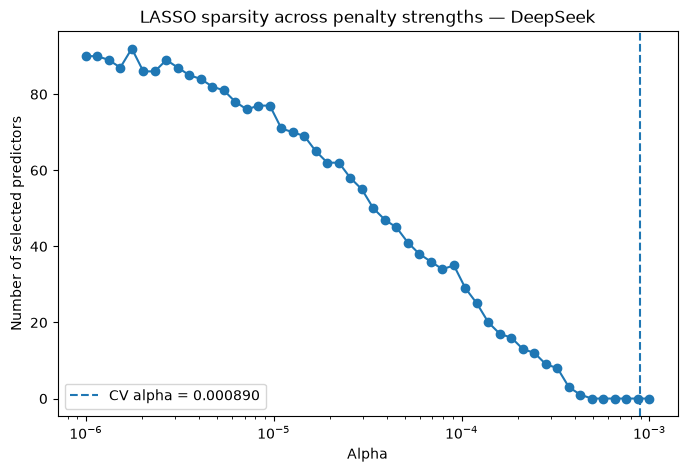

In [52]:
# LASSO sparsity path

plt.figure(figsize=(8, 5))

plt.semilogx(
    alpha_selection["alpha"],
    alpha_selection["n_selected"],
    marker="o"
)

plt.axvline(
    best_alpha_deepseek,
    linestyle="--",
    label=f"CV alpha = {best_alpha_deepseek:.6f}"
)

plt.xlabel("Alpha")
plt.ylabel("Number of selected predictors")
plt.title("LASSO sparsity across penalty strengths — DeepSeek")
plt.legend()

plt.show()

In [53]:
# Extract DeepSeek CV performance across alpha

cv_results_deepseek = pd.DataFrame(
    lasso_search_deepseek.cv_results_
)

cv_curve_deepseek = pd.DataFrame({
    "alpha": cv_results_deepseek["param_lasso__alpha"].astype(float),
    "cv_mse": -cv_results_deepseek["mean_test_score"],
    "cv_std": cv_results_deepseek["std_test_score"]
})

cv_curve_deepseek = (
    cv_curve_deepseek
    .sort_values("alpha")
    .reset_index(drop=True)
)

display(
    cv_curve_deepseek
    .sort_values("cv_mse")
    .head(15)
)

,alpha,cv_mse,cv_std
80,0.001707,0.000016,0.000004
81,0.001874,0.000016,0.000004
82,0.002057,0.000016,0.000004
83,0.002257,0.000016,0.000004
84,0.002477,0.000016,0.000004
97,0.008302,0.000016,0.000004
98,0.009112,0.000016,0.000004
99,0.010000,0.000016,0.000004
96,0.007565,0.000016,0.000004
95,0.006893,0.000016,0.000004


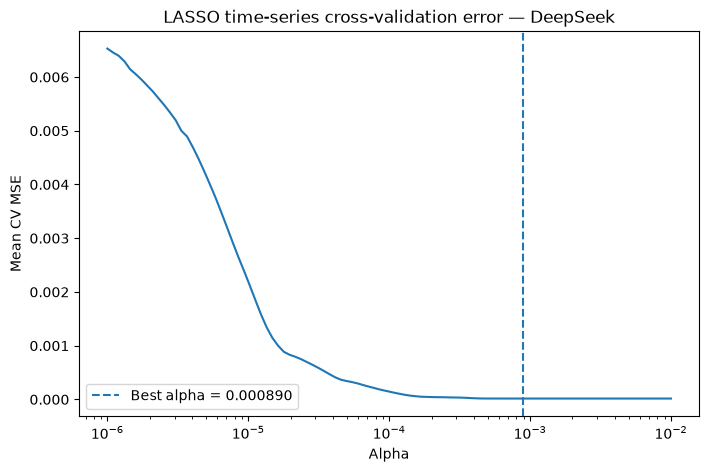

In [54]:
# LASSO CV error curve

plt.figure(figsize=(8, 5))

plt.semilogx(
    cv_curve_deepseek["alpha"],
    cv_curve_deepseek["cv_mse"]
)

plt.axvline(
    best_alpha_deepseek,
    linestyle="--",
    label=f"Best alpha = {best_alpha_deepseek:.6f}"
)

plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LASSO time-series cross-validation error — DeepSeek")
plt.legend()

plt.show()

In [55]:
# Compare best CV model with weakly penalised models

best_row = cv_curve_deepseek.loc[
    cv_curve_deepseek["cv_mse"].idxmin()
]

print("Best alpha:", best_row["alpha"])
print("Best CV MSE:", best_row["cv_mse"])

for alpha_check in [1e-6, 1e-5, 1e-4, 5e-4, 1e-3]:
    
    idx = (
        cv_curve_deepseek["alpha"] - alpha_check
    ).abs().idxmin()
    
    row = cv_curve_deepseek.loc[idx]
    
    print(
        f"\nAlpha ≈ {row['alpha']:.8f}"
        f"\nCV MSE = {row['cv_mse']:.10f}"
    )

Best alpha: 0.0008902150854450393
Best CV MSE: 1.57711241805162e-05

Alpha ≈ 0.00000100
CV MSE = 0.0065301248

Alpha ≈ 0.00001024
CV MSE = 0.0021249428

Alpha ≈ 0.00009545
CV MSE = 0.0001568030

Alpha ≈ 0.00050941
CV MSE = 0.0000163542

Alpha ≈ 0.00097701
CV MSE = 0.0000157711


In [56]:
# Final test predictions

y_pred_deepseek = best_model_deepseek.predict(
    X_test_deepseek
)

y_pred_gemma = best_model_gemma.predict(
    X_test_gemma
)

In [57]:
# Historical-mean benchmark

mean_forecast = np.repeat(
    y_train.mean(),
    len(y_test)
)

In [58]:
def evaluate_forecast(y_true, y_pred):
    return {
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


results = pd.DataFrame({
    "DeepSeek_LASSO": evaluate_forecast(
        y_test,
        y_pred_deepseek
    ),
    "Gemma_LASSO": evaluate_forecast(
        y_test,
        y_pred_gemma
    ),
    "Mean_Benchmark": evaluate_forecast(
        y_test,
        mean_forecast
    )
}).T

display(results)

,RMSE,MAE,R2
DeepSeek_LASSO,0.004286,0.003365,-0.024624
Gemma_LASSO,0.004286,0.003365,-0.024624
Mean_Benchmark,0.004286,0.003365,-0.024624


In [59]:
# Add zero-return benchmark

zero_results = evaluate_forecast(
    y_test,
    np.zeros(len(y_test))
)

results.loc["Zero_Benchmark"] = zero_results

display(results)

,RMSE,MAE,R2
DeepSeek_LASSO,0.004286,0.003365,-0.024624
Gemma_LASSO,0.004286,0.003365,-0.024624
Mean_Benchmark,0.004286,0.003365,-0.024624
Zero_Benchmark,0.004287,0.003366,-0.024999


In [60]:
# Final LASSO test-set comparison

results = pd.DataFrame({
    "DeepSeek_LASSO": evaluate_forecast(
        y_test, y_pred_deepseek
    ),
    "Gemma_LASSO": evaluate_forecast(
        y_test, y_pred_gemma
    ),
    "Mean_Benchmark": evaluate_forecast(
        y_test, mean_forecast
    ),
    "Zero_Benchmark": evaluate_forecast(
        y_test, np.zeros(len(y_test))
    )
}).T

display(results)

,RMSE,MAE,R2
DeepSeek_LASSO,0.004286,0.003365,-0.024624
Gemma_LASSO,0.004286,0.003365,-0.024624
Mean_Benchmark,0.004286,0.003365,-0.024624
Zero_Benchmark,0.004287,0.003366,-0.024999


In [61]:
# Final LASSO summary

lasso_summary = pd.DataFrame({
    "model": [
        "DeepSeek_LASSO",
        "Gemma_LASSO"
    ],
    "best_alpha": [
        best_alpha_deepseek,
        best_alpha_gemma
    ],
    "cv_mse": [
        -lasso_search_deepseek.best_score_,
        -lasso_search_gemma.best_score_
    ],
    "n_candidate_features": [
        len(FEATURE_COLS),
        len(FEATURE_COLS)
    ],
    "n_selected_features": [
        np.count_nonzero(lasso_deepseek.coef_),
        np.count_nonzero(lasso_gemma.coef_)
    ],
    "test_rmse": [
        results.loc["DeepSeek_LASSO", "RMSE"],
        results.loc["Gemma_LASSO", "RMSE"]
    ],
    "test_mae": [
        results.loc["DeepSeek_LASSO", "MAE"],
        results.loc["Gemma_LASSO", "MAE"]
    ],
    "test_r2": [
        results.loc["DeepSeek_LASSO", "R2"],
        results.loc["Gemma_LASSO", "R2"]
    ]
})

display(lasso_summary)

,model,best_alpha,cv_mse,n_candidate_features,n_selected_features,test_rmse,test_mae,test_r2
0,DeepSeek_LASSO,0.000890,0.000016,124,0,0.004286,0.003365,-0.024624
1,Gemma_LASSO,0.000811,0.000016,124,0,0.004286,0.003365,-0.024624


In [62]:
# Complete coefficient tables

lasso_coefficients_deepseek = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": lasso_deepseek.coef_,
    "abs_coefficient": np.abs(lasso_deepseek.coef_)
})

lasso_coefficients_gemma = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": lasso_gemma.coef_,
    "abs_coefficient": np.abs(lasso_gemma.coef_)
})

display(lasso_coefficients_deepseek.head())
display(lasso_coefficients_gemma.head())

,feature,coefficient,abs_coefficient
0,DGS2,0.0,0.0
1,USEPUINDXD,0.0,0.0
2,VIXCLS,0.0,0.0
3,DGS2_diff,0.0,0.0
4,DGS2_lag1,0.0,0.0


,feature,coefficient,abs_coefficient
0,DGS2,0.0,0.0
1,USEPUINDXD,0.0,0.0
2,VIXCLS,0.0,0.0
3,DGS2_diff,0.0,0.0
4,DGS2_lag1,0.0,0.0


In [63]:
# Test-set predictions

lasso_predictions = pd.DataFrame({
    "observation_date": dates_test.values,
    "actual": y_test.values,
    "deepseek_lasso": y_pred_deepseek,
    "gemma_lasso": y_pred_gemma,
    "mean_benchmark": mean_forecast,
    "zero_benchmark": np.zeros(len(y_test))
})

display(lasso_predictions.head())

,observation_date,actual,deepseek_lasso,gemma_lasso,mean_benchmark,zero_benchmark
0,2020-03-23,0.003155,0.000005,0.000005,0.000005,0.0
1,2020-03-24,0.003791,0.000005,0.000005,0.000005,0.0
2,2020-03-25,0.017384,0.000005,0.000005,0.000005,0.0
3,2020-03-26,0.003079,0.000005,0.000005,0.000005,0.0
4,2020-03-27,-0.003714,0.000005,0.000005,0.000005,0.0


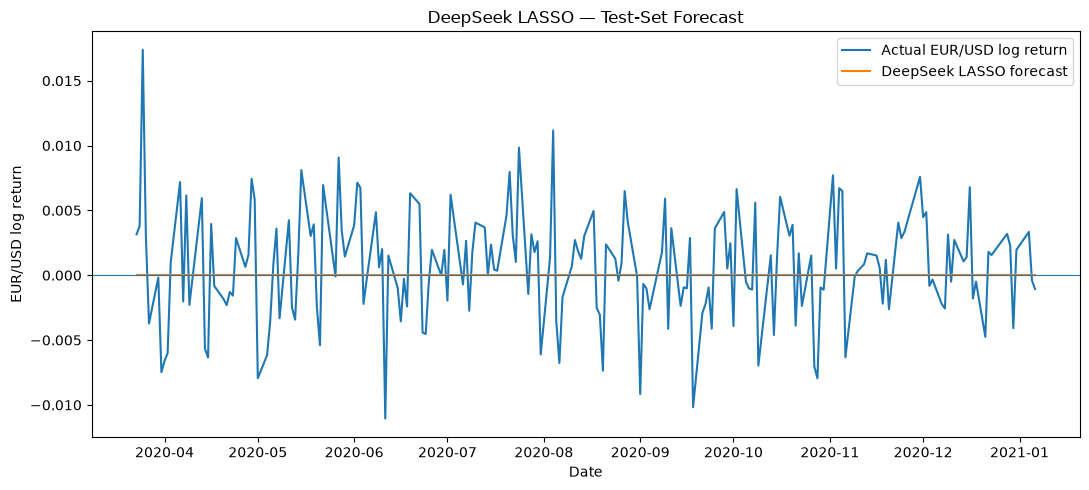

In [64]:
# DeepSeek LASSO test forecast

plt.figure(figsize=(11, 5))

plt.plot(
    lasso_predictions["observation_date"],
    lasso_predictions["actual"],
    label="Actual EUR/USD log return"
)

plt.plot(
    lasso_predictions["observation_date"],
    lasso_predictions["deepseek_lasso"],
    label="DeepSeek LASSO forecast"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel("Date")
plt.ylabel("EUR/USD log return")
plt.title("DeepSeek LASSO — Test-Set Forecast")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "lasso_deepseek_test_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
# Save LASSO outputs

lasso_summary.to_csv(
    OUTPUT_DIR / "lasso_summary.csv",
    index=False
)

results.to_csv(
    OUTPUT_DIR / "lasso_test_metrics.csv"
)

lasso_coefficients_deepseek.to_csv(
    OUTPUT_DIR / "lasso_coefficients_deepseek.csv",
    index=False
)

lasso_coefficients_gemma.to_csv(
    OUTPUT_DIR / "lasso_coefficients_gemma.csv",
    index=False
)

lasso_predictions.to_csv(
    OUTPUT_DIR / "lasso_test_predictions.csv",
    index=False
)

cv_curve_deepseek.to_csv(
    OUTPUT_DIR / "lasso_cv_curve_deepseek.csv",
    index=False
)

print("LASSO outputs saved to:")
print(OUTPUT_DIR.resolve())

LASSO outputs saved to:
C:\Users\franc\OneDrive\Geop-Model\outputs\lasso\lasso_candidate_features


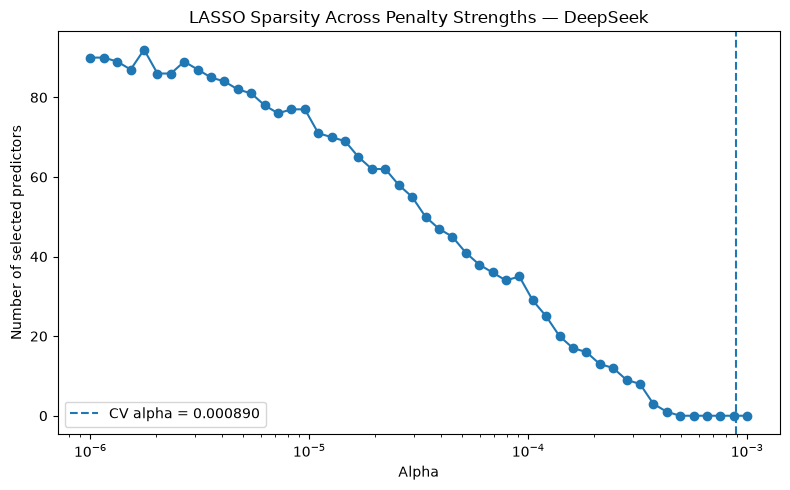

In [66]:
# Save DeepSeek LASSO sparsity path

plt.figure(figsize=(8, 5))

plt.semilogx(
    alpha_selection["alpha"],
    alpha_selection["n_selected"],
    marker="o"
)

plt.axvline(
    best_alpha_deepseek,
    linestyle="--",
    label=f"CV alpha = {best_alpha_deepseek:.6f}"
)

plt.xlabel("Alpha")
plt.ylabel("Number of selected predictors")
plt.title("LASSO Sparsity Across Penalty Strengths — DeepSeek")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "lasso_deepseek_sparsity_path.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

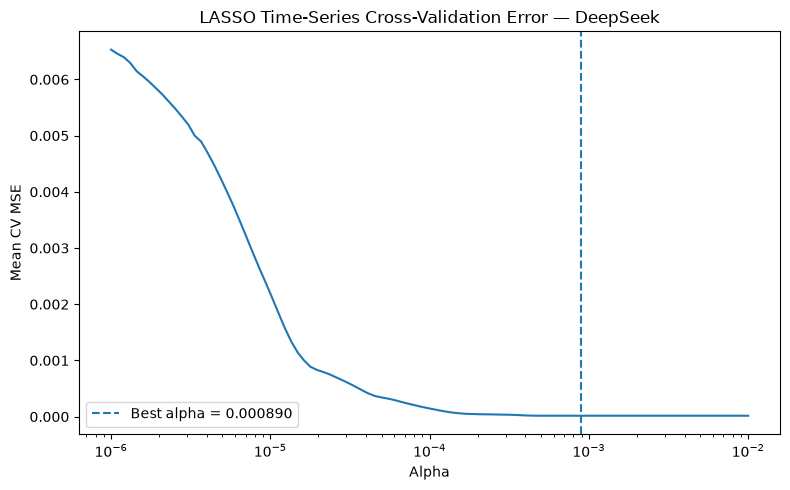

In [67]:
# Save LASSO CV error curve

plt.figure(figsize=(8, 5))

plt.semilogx(
    cv_curve_deepseek["alpha"],
    cv_curve_deepseek["cv_mse"]
)

plt.axvline(
    best_alpha_deepseek,
    linestyle="--",
    label=f"Best alpha = {best_alpha_deepseek:.6f}"
)

plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LASSO Time-Series Cross-Validation Error — DeepSeek")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "lasso_deepseek_cv_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
# Final LASSO notebook summary

print("=" * 55)
print("LASSO CANDIDATE-FEATURE ANALYSIS COMPLETE")
print("=" * 55)

print(f"Candidate predictors: {len(FEATURE_COLS)}")
print(f"Training observations: {len(y_train)}")
print(f"Test observations: {len(y_test)}")

print("\nDeepSeek")
print(f"Best alpha: {best_alpha_deepseek:.8f}")
print(f"Selected predictors: {np.count_nonzero(lasso_deepseek.coef_)}")

print("\nGemma")
print(f"Best alpha: {best_alpha_gemma:.8f}")
print(f"Selected predictors: {np.count_nonzero(lasso_gemma.coef_)}")

print("\nTest RMSE")
print(
    "DeepSeek:",
    results.loc["DeepSeek_LASSO", "RMSE"]
)
print(
    "Gemma:",
    results.loc["Gemma_LASSO", "RMSE"]
)
print(
    "Mean benchmark:",
    results.loc["Mean_Benchmark", "RMSE"]
)
print(
    "Zero benchmark:",
    results.loc["Zero_Benchmark", "RMSE"]
)

print("\nOutputs:")
print(OUTPUT_DIR.resolve())

LASSO CANDIDATE-FEATURE ANALYSIS COMPLETE
Candidate predictors: 124
Training observations: 784
Test observations: 197

DeepSeek
Best alpha: 0.00089022
Selected predictors: 0

Gemma
Best alpha: 0.00081113
Selected predictors: 0

Test RMSE
DeepSeek: 0.0042861051043039415
Gemma: 0.0042861051043039415
Mean benchmark: 0.0042861051043039415
Zero benchmark: 0.004286889580202056

Outputs:
C:\Users\franc\OneDrive\Geop-Model\outputs\lasso\lasso_candidate_features


In [69]:
# Robustness check — old restricted 18-feature universe

restricted_features = [
    "DGS2_diff",
    "USEPUINDXD_diff",
    "VIXCLS",

    "trade_sum",
    "sanctions_sum",
    "fed_pressure_sum",

    "trade_max",
    "sanctions_max",
    "fed_pressure_max",

    "trade_sum_ma3",
    "sanctions_sum_ma3",
    "fed_pressure_sum_ma3",

    "trade_sum_ma5",
    "sanctions_sum_ma5",
    "fed_pressure_sum_ma5",

    "trade_sum_ma10",
    "sanctions_sum_ma10",
    "fed_pressure_sum_ma10"
]

print("Restricted feature count:", len(restricted_features))

Restricted feature count: 18


In [70]:
# Restricted DeepSeek/Gemma predictor matrices

X_restricted_deepseek = deepseek_model[restricted_features].copy()
X_restricted_gemma = gemma_model[restricted_features].copy()

X_train_restricted_deepseek = X_restricted_deepseek.iloc[:split_idx]
X_test_restricted_deepseek = X_restricted_deepseek.iloc[split_idx:]

X_train_restricted_gemma = X_restricted_gemma.iloc[:split_idx]
X_test_restricted_gemma = X_restricted_gemma.iloc[split_idx:]

In [71]:
# Restricted LASSO — DeepSeek

restricted_pipe_deepseek = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=100000))
])

restricted_search_deepseek = GridSearchCV(
    estimator=restricted_pipe_deepseek,
    param_grid={"lasso__alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

restricted_search_deepseek.fit(
    X_train_restricted_deepseek,
    y_train
)

print(
    "Restricted DeepSeek alpha:",
    restricted_search_deepseek.best_params_["lasso__alpha"]
)

Restricted DeepSeek alpha: 0.0005590810182512228


In [72]:
# Restricted LASSO — Gemma

restricted_pipe_gemma = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=100000))
])

restricted_search_gemma = GridSearchCV(
    estimator=restricted_pipe_gemma,
    param_grid={"lasso__alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

restricted_search_gemma.fit(
    X_train_restricted_gemma,
    y_train
)

print(
    "Restricted Gemma alpha:",
    restricted_search_gemma.best_params_["lasso__alpha"]
)

Restricted Gemma alpha: 0.0004229242874389499


In [73]:
# Selected predictors — restricted universe

restricted_lasso_deepseek = (
    restricted_search_deepseek.best_estimator_
    .named_steps["lasso"]
)

restricted_lasso_gemma = (
    restricted_search_gemma.best_estimator_
    .named_steps["lasso"]
)

restricted_coef_deepseek = pd.DataFrame({
    "feature": restricted_features,
    "coefficient": restricted_lasso_deepseek.coef_
})

restricted_coef_gemma = pd.DataFrame({
    "feature": restricted_features,
    "coefficient": restricted_lasso_gemma.coef_
})

restricted_selected_deepseek = (
    restricted_coef_deepseek[
        restricted_coef_deepseek["coefficient"] != 0
    ]
    .copy()
    .sort_values("coefficient", key=abs, ascending=False)
)

restricted_selected_gemma = (
    restricted_coef_gemma[
        restricted_coef_gemma["coefficient"] != 0
    ]
    .copy()
    .sort_values("coefficient", key=abs, ascending=False)
)

print("DEEPSEEK")
display(restricted_selected_deepseek)

print("\nGEMMA")
display(restricted_selected_gemma)

DEEPSEEK


,feature,coefficient



GEMMA


,feature,coefficient
2,VIXCLS,-1.101908e-05
0,DGS2_diff,-7.768128e-07


In [74]:
print(
    "DeepSeek restricted alpha:",
    restricted_search_deepseek.best_params_["lasso__alpha"]
)

print(
    "DeepSeek restricted CV MSE:",
    -restricted_search_deepseek.best_score_
)

print(
    "\nGemma restricted alpha:",
    restricted_search_gemma.best_params_["lasso__alpha"]
)

print(
    "Gemma restricted CV MSE:",
    -restricted_search_gemma.best_score_
)

print(
    "\nDeepSeek selected:",
    len(restricted_selected_deepseek)
)

print(
    "Gemma selected:",
    len(restricted_selected_gemma)
)

DeepSeek restricted alpha: 0.0005590810182512228
DeepSeek restricted CV MSE: 1.5737456385485083e-05

Gemma restricted alpha: 0.0004229242874389499
Gemma restricted CV MSE: 1.5667485279645415e-05

DeepSeek selected: 0
Gemma selected: 2


In [75]:
# Restricted coefficient-path diagnostic

alpha_path = np.logspace(-6, -3, 100)

features_to_track = [
    "VIXCLS",
    "DGS2_diff",
    "sanctions_sum_ma10"
]

path_rows = []

for alpha in alpha_path:

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=100000))
    ])

    pipe.fit(
        X_train_restricted_gemma,
        y_train
    )

    coefs = pipe.named_steps["lasso"].coef_

    coef_map = dict(
        zip(restricted_features, coefs)
    )

    path_rows.append({
        "alpha": alpha,
        "VIXCLS": coef_map["VIXCLS"],
        "DGS2_diff": coef_map["DGS2_diff"],
        "sanctions_sum_ma10": coef_map["sanctions_sum_ma10"]
    })

restricted_path_gemma = pd.DataFrame(path_rows)

display(restricted_path_gemma.head())

,alpha,VIXCLS,DGS2_diff,sanctions_sum_ma10
0,0.000001,-0.000559,-0.000515,-0.000484
1,0.000001,-0.000559,-0.000514,-0.000484
2,0.000001,-0.000559,-0.000514,-0.000484
3,0.000001,-0.000559,-0.000514,-0.000484
4,0.000001,-0.000559,-0.000514,-0.000484


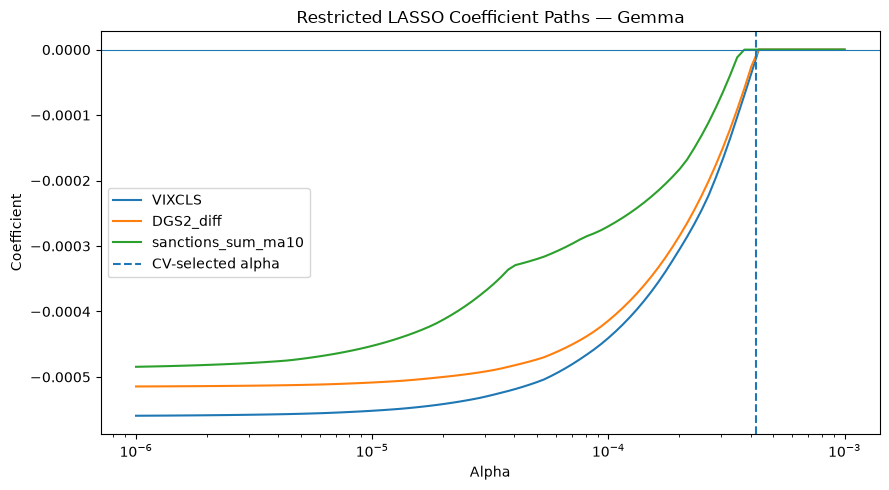

In [76]:
# Restricted Gemma coefficient paths

plt.figure(figsize=(9, 5))

for feature in features_to_track:
    plt.semilogx(
        restricted_path_gemma["alpha"],
        restricted_path_gemma[feature],
        label=feature
    )

plt.axvline(
    restricted_search_gemma.best_params_["lasso__alpha"],
    linestyle="--",
    label="CV-selected alpha"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Restricted LASSO Coefficient Paths — Gemma")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "restricted_lasso_coefficient_paths_gemma.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
# Full vs restricted LASSO comparison

lasso_comparison = pd.DataFrame({
    "model": [
        "DeepSeek_full_124",
        "Gemma_full_124",
        "DeepSeek_restricted_18",
        "Gemma_restricted_18"
    ],
    "n_features": [
        124,
        124,
        18,
        18
    ],
    "best_alpha": [
        best_alpha_deepseek,
        best_alpha_gemma,
        restricted_search_deepseek.best_params_["lasso__alpha"],
        restricted_search_gemma.best_params_["lasso__alpha"]
    ],
    "cv_mse": [
        -lasso_search_deepseek.best_score_,
        -lasso_search_gemma.best_score_,
        -restricted_search_deepseek.best_score_,
        -restricted_search_gemma.best_score_
    ],
    "n_selected": [
        np.count_nonzero(lasso_deepseek.coef_),
        np.count_nonzero(lasso_gemma.coef_),
        np.count_nonzero(restricted_lasso_deepseek.coef_),
        np.count_nonzero(restricted_lasso_gemma.coef_)
    ]
})

display(lasso_comparison)

,model,n_features,best_alpha,cv_mse,n_selected
0,DeepSeek_full_124,124,0.000890,0.000016,0
1,Gemma_full_124,124,0.000811,0.000016,0
2,DeepSeek_restricted_18,18,0.000559,0.000016,0
3,Gemma_restricted_18,18,0.000423,0.000016,2


In [78]:
print("Restricted DeepSeek selected:")
display(restricted_selected_deepseek)

print("\nRestricted Gemma selected:")
display(restricted_selected_gemma)

Restricted DeepSeek selected:


,feature,coefficient



Restricted Gemma selected:


,feature,coefficient
2,VIXCLS,-1.101908e-05
0,DGS2_diff,-7.768128e-07


In [79]:
# Save restricted-LASSO robustness outputs

restricted_coef_deepseek.to_csv(
    OUTPUT_DIR / "restricted_lasso_coefficients_deepseek.csv",
    index=False
)

restricted_coef_gemma.to_csv(
    OUTPUT_DIR / "restricted_lasso_coefficients_gemma.csv",
    index=False
)

restricted_selected_deepseek.to_csv(
    OUTPUT_DIR / "restricted_lasso_selected_deepseek.csv",
    index=False
)

restricted_selected_gemma.to_csv(
    OUTPUT_DIR / "restricted_lasso_selected_gemma.csv",
    index=False
)

lasso_comparison.to_csv(
    OUTPUT_DIR / "lasso_full_vs_restricted_summary.csv",
    index=False
)

restricted_path_gemma.to_csv(
    OUTPUT_DIR / "restricted_lasso_coefficient_path_gemma.csv",
    index=False
)

print("Restricted LASSO robustness outputs saved.")

Restricted LASSO robustness outputs saved.


In [80]:
# General restricted LASSO coefficient paths — Gemma

alpha_path = np.logspace(-6, -3, 100)

path_rows = []

for alpha in alpha_path:

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(
            alpha=alpha,
            max_iter=100000
        ))
    ])

    pipe.fit(
        X_train_restricted_gemma,
        y_train
    )

    coefs = pipe.named_steps["lasso"].coef_

    row = {"alpha": alpha}

    for feature, coef in zip(
        restricted_features,
        coefs
    ):
        row[feature] = coef

    path_rows.append(row)

restricted_path_all_gemma = pd.DataFrame(path_rows)

display(restricted_path_all_gemma.head())

,alpha,DGS2_diff,USEPUINDXD_diff,VIXCLS,trade_sum,sanctions_sum,fed_pressure_sum,trade_max,sanctions_max,fed_pressure_max,trade_sum_ma3,sanctions_sum_ma3,fed_pressure_sum_ma3,trade_sum_ma5,sanctions_sum_ma5,fed_pressure_sum_ma5,trade_sum_ma10,sanctions_sum_ma10,fed_pressure_sum_ma10
0,0.000001,-0.000515,0.000202,-0.000559,0.000108,-0.000583,-0.000284,-0.000072,0.000427,0.000339,-0.000178,-0.000168,0.000046,0.000254,0.000293,0.000408,-0.000015,-0.000484,-0.000662
1,0.000001,-0.000514,0.000202,-0.000559,0.000108,-0.000582,-0.000283,-0.000071,0.000425,0.000339,-0.000177,-0.000168,0.000045,0.000253,0.000293,0.000407,-0.000015,-0.000484,-0.000661
2,0.000001,-0.000514,0.000202,-0.000559,0.000107,-0.000581,-0.000282,-0.000071,0.000424,0.000338,-0.000176,-0.000168,0.000044,0.000252,0.000292,0.000407,-0.000015,-0.000484,-0.000660
3,0.000001,-0.000514,0.000202,-0.000559,0.000106,-0.000579,-0.000281,-0.000070,0.000423,0.000337,-0.000175,-0.000167,0.000044,0.000250,0.000292,0.000407,-0.000014,-0.000484,-0.000660
4,0.000001,-0.000514,0.000202,-0.000559,0.000105,-0.000578,-0.000280,-0.000070,0.000421,0.000337,-0.000174,-0.000167,0.000043,0.000249,0.000291,0.000407,-0.000014,-0.000484,-0.000659


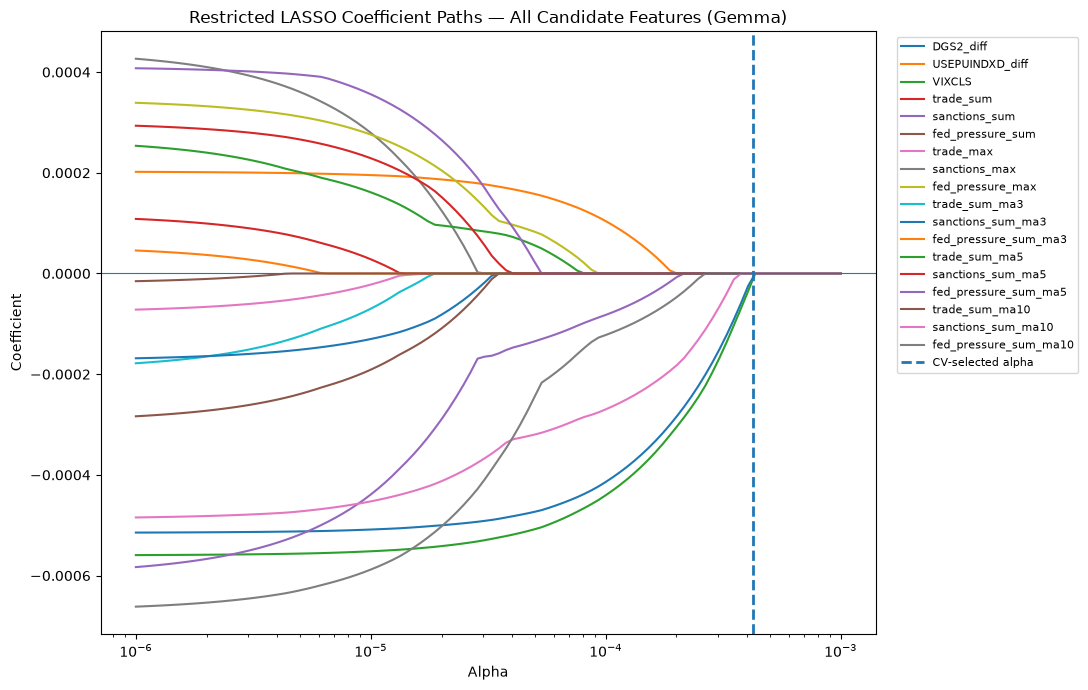

In [81]:
# Plot all restricted coefficient paths — Gemma

plt.figure(figsize=(11, 7))

for feature in restricted_features:

    plt.semilogx(
        restricted_path_all_gemma["alpha"],
        restricted_path_all_gemma[feature],
        label=feature
    )

plt.axvline(
    restricted_search_gemma.best_params_["lasso__alpha"],
    linestyle="--",
    linewidth=2,
    label="CV-selected alpha"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title(
    "Restricted LASSO Coefficient Paths — All Candidate Features (Gemma)"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "restricted_lasso_all_coefficient_paths_gemma.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
# Approximate largest alpha at which each feature remains non-zero

survival_rows = []

for feature in restricted_features:

    nonzero = restricted_path_all_gemma[
        ~np.isclose(
            restricted_path_all_gemma[feature],
            0.0
        )
    ]

    if len(nonzero) > 0:
        max_alpha_nonzero = nonzero["alpha"].max()
    else:
        max_alpha_nonzero = np.nan

    survival_rows.append({
        "feature": feature,
        "max_alpha_nonzero": max_alpha_nonzero
    })

survival_gemma = (
    pd.DataFrame(survival_rows)
    .sort_values(
        "max_alpha_nonzero",
        ascending=False
    )
    .reset_index(drop=True)
)

display(survival_gemma)

,feature,max_alpha_nonzero
0,DGS2_diff,0.000404
1,VIXCLS,0.000404
2,sanctions_sum_ma10,0.000351
3,fed_pressure_sum_ma10,0.000248
4,sanctions_sum,0.000201
5,USEPUINDXD_diff,0.000187
6,fed_pressure_max,0.000087
7,trade_sum_ma5,0.000076
8,fed_pressure_sum_ma5,0.000050
9,sanctions_sum_ma5,0.000038


In [83]:
# General restricted LASSO coefficient paths — DeepSeek

alpha_path = np.logspace(-6, -3, 100)

path_rows = []

for alpha in alpha_path:

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(
            alpha=alpha,
            max_iter=100000
        ))
    ])

    pipe.fit(
        X_train_restricted_deepseek,
        y_train
    )

    coefs = pipe.named_steps["lasso"].coef_

    row = {"alpha": alpha}

    for feature, coef in zip(
        restricted_features,
        coefs
    ):
        row[feature] = coef

    path_rows.append(row)

restricted_path_all_deepseek = pd.DataFrame(path_rows)

display(restricted_path_all_deepseek.head())

,alpha,DGS2_diff,USEPUINDXD_diff,VIXCLS,trade_sum,sanctions_sum,fed_pressure_sum,trade_max,sanctions_max,fed_pressure_max,trade_sum_ma3,sanctions_sum_ma3,fed_pressure_sum_ma3,trade_sum_ma5,sanctions_sum_ma5,fed_pressure_sum_ma5,trade_sum_ma10,sanctions_sum_ma10,fed_pressure_sum_ma10
0,0.000001,-0.000515,0.0002,-0.000533,0.000033,-0.000209,-0.000069,0.000126,0.000160,0.000100,-0.000596,0.000113,0.000127,0.000854,-0.000062,0.000022,-0.000441,-0.000262,-0.000210
1,0.000001,-0.000515,0.0002,-0.000533,0.000033,-0.000208,-0.000068,0.000126,0.000159,0.000099,-0.000595,0.000112,0.000126,0.000853,-0.000062,0.000022,-0.000441,-0.000262,-0.000209
2,0.000001,-0.000515,0.0002,-0.000533,0.000033,-0.000207,-0.000067,0.000126,0.000158,0.000099,-0.000594,0.000111,0.000126,0.000852,-0.000061,0.000022,-0.000440,-0.000262,-0.000209
3,0.000001,-0.000515,0.0002,-0.000532,0.000032,-0.000205,-0.000066,0.000126,0.000157,0.000098,-0.000593,0.000110,0.000125,0.000850,-0.000060,0.000022,-0.000440,-0.000262,-0.000208
4,0.000001,-0.000515,0.0002,-0.000532,0.000032,-0.000204,-0.000065,0.000126,0.000156,0.000097,-0.000591,0.000109,0.000125,0.000848,-0.000059,0.000021,-0.000439,-0.000262,-0.000208


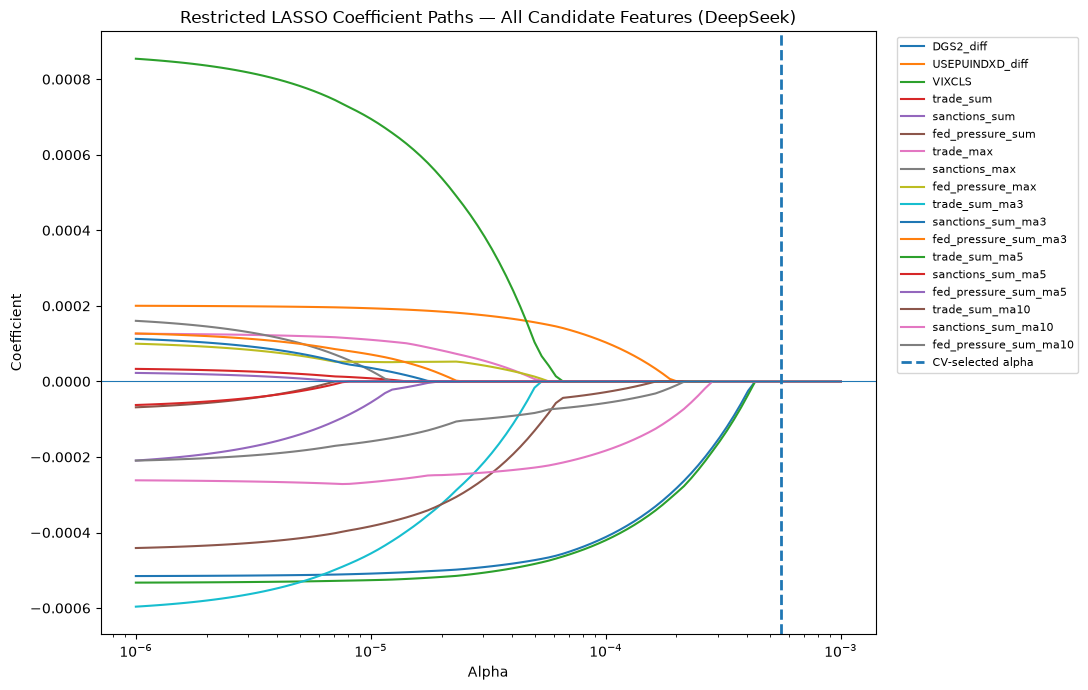

In [84]:
# Plot all restricted coefficient paths — DeepSeek

plt.figure(figsize=(11, 7))

for feature in restricted_features:

    plt.semilogx(
        restricted_path_all_deepseek["alpha"],
        restricted_path_all_deepseek[feature],
        label=feature
    )

plt.axvline(
    restricted_search_deepseek.best_params_["lasso__alpha"],
    linestyle="--",
    linewidth=2,
    label="CV-selected alpha"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel("Alpha")
plt.ylabel("Coefficient")

plt.title(
    "Restricted LASSO Coefficient Paths — All Candidate Features (DeepSeek)"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "restricted_lasso_all_coefficient_paths_deepseek.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
# Approximate largest alpha at which each DeepSeek feature remains non-zero

survival_rows = []

for feature in restricted_features:

    nonzero = restricted_path_all_deepseek[
        ~np.isclose(
            restricted_path_all_deepseek[feature],
            0.0
        )
    ]

    if len(nonzero) > 0:
        max_alpha_nonzero = nonzero["alpha"].max()
    else:
        max_alpha_nonzero = np.nan

    survival_rows.append({
        "feature": feature,
        "max_alpha_nonzero": max_alpha_nonzero
    })

survival_deepseek = (
    pd.DataFrame(survival_rows)
    .sort_values(
        "max_alpha_nonzero",
        ascending=False
    )
    .reset_index(drop=True)
)

display(survival_deepseek)

,feature,max_alpha_nonzero
0,DGS2_diff,0.000404
1,VIXCLS,0.000404
2,sanctions_sum_ma10,0.000266
3,fed_pressure_sum_ma10,0.000215
4,USEPUINDXD_diff,0.000187
5,trade_sum_ma10,0.000163
6,trade_sum_ma5,0.000061
7,trade_max,0.000057
8,fed_pressure_max,0.000053
9,trade_sum_ma3,0.000050


In [86]:
# Save complete restricted coefficient-path diagnostics

restricted_path_all_deepseek.to_csv(
    OUTPUT_DIR / "restricted_lasso_all_paths_deepseek.csv",
    index=False
)

restricted_path_all_gemma.to_csv(
    OUTPUT_DIR / "restricted_lasso_all_paths_gemma.csv",
    index=False
)

survival_deepseek.to_csv(
    OUTPUT_DIR / "restricted_lasso_survival_ranking_deepseek.csv",
    index=False
)

survival_gemma.to_csv(
    OUTPUT_DIR / "restricted_lasso_survival_ranking_gemma.csv",
    index=False
)

print("Complete restricted LASSO path diagnostics saved.")

Complete restricted LASSO path diagnostics saved.


In [87]:
# Focused diagnostic:
# all macro representations + geopolitical MA10

macro_all_features = [
    col for col in FEATURE_COLS
    if col.startswith(
        ("DGS2", "USEPUINDXD", "VIXCLS")
    )
]

geopolitical_ma10 = [
    "trade_sum_ma10",
    "sanctions_sum_ma10",
    "fed_pressure_sum_ma10"
]

macro_ma10_features = (
    macro_all_features
    + geopolitical_ma10
)

print("Macro candidates:", len(macro_all_features))
print("Total focused candidates:", len(macro_ma10_features))

print("\nMacro candidates:")
for feature in macro_all_features:
    print(feature)

Macro candidates: 39
Total focused candidates: 42

Macro candidates:
DGS2
USEPUINDXD
VIXCLS
DGS2_diff
DGS2_lag1
DGS2_lag2
DGS2_lag3
DGS2_lag5
DGS2_diff_lag1
DGS2_diff_lag2
DGS2_diff_lag3
DGS2_diff_lag5
DGS2_ma3
DGS2_ma5
DGS2_ma10
USEPUINDXD_diff
USEPUINDXD_lag1
USEPUINDXD_lag2
USEPUINDXD_lag3
USEPUINDXD_lag5
USEPUINDXD_diff_lag1
USEPUINDXD_diff_lag2
USEPUINDXD_diff_lag3
USEPUINDXD_diff_lag5
USEPUINDXD_ma3
USEPUINDXD_ma5
USEPUINDXD_ma10
VIXCLS_diff
VIXCLS_lag1
VIXCLS_lag2
VIXCLS_lag3
VIXCLS_lag5
VIXCLS_diff_lag1
VIXCLS_diff_lag2
VIXCLS_diff_lag3
VIXCLS_diff_lag5
VIXCLS_ma3
VIXCLS_ma5
VIXCLS_ma10


In [88]:
# All macro representations + geopolitical MA10

X_macro_ma10_deepseek = (
    deepseek_model[macro_ma10_features].copy()
)

X_macro_ma10_gemma = (
    gemma_model[macro_ma10_features].copy()
)

X_train_macro_ma10_deepseek = (
    X_macro_ma10_deepseek.iloc[:split_idx]
)

X_test_macro_ma10_deepseek = (
    X_macro_ma10_deepseek.iloc[split_idx:]
)

X_train_macro_ma10_gemma = (
    X_macro_ma10_gemma.iloc[:split_idx]
)

X_test_macro_ma10_gemma = (
    X_macro_ma10_gemma.iloc[split_idx:]
)

print("DeepSeek:", X_macro_ma10_deepseek.shape)
print("Gemma:", X_macro_ma10_gemma.shape)

DeepSeek: (981, 42)
Gemma: (981, 42)


In [89]:
def run_lasso_search(X_train, y_train):

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(max_iter=100000))
    ])

    search = GridSearchCV(
        estimator=pipe,
        param_grid={
            "lasso__alpha": alphas
        },
        scoring="neg_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    return search


macro_ma10_search_deepseek = run_lasso_search(
    X_train_macro_ma10_deepseek,
    y_train
)

macro_ma10_search_gemma = run_lasso_search(
    X_train_macro_ma10_gemma,
    y_train
)

print(
    "DeepSeek alpha:",
    macro_ma10_search_deepseek.best_params_["lasso__alpha"]
)

print(
    "Gemma alpha:",
    macro_ma10_search_gemma.best_params_["lasso__alpha"]
)

DeepSeek alpha: 0.0008111308307896872
Gemma alpha: 0.0008111308307896872


In [90]:
def extract_selected(search, feature_names):

    model = (
        search.best_estimator_
        .named_steps["lasso"]
    )

    table = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model.coef_
    })

    selected = (
        table[
            ~np.isclose(
                table["coefficient"],
                0.0
            )
        ]
        .copy()
        .sort_values(
            "coefficient",
            key=abs,
            ascending=False
        )
    )

    return table, selected


macro_ma10_coef_deepseek, macro_ma10_selected_deepseek = (
    extract_selected(
        macro_ma10_search_deepseek,
        macro_ma10_features
    )
)

macro_ma10_coef_gemma, macro_ma10_selected_gemma = (
    extract_selected(
        macro_ma10_search_gemma,
        macro_ma10_features
    )
)

print("DEEPSEEK")
display(macro_ma10_selected_deepseek)

print("\nGEMMA")
display(macro_ma10_selected_gemma)

DEEPSEEK


,feature,coefficient



GEMMA


,feature,coefficient
